<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/StyleGAN2_ADA_untuk_Sintesis_Citra_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Cell 01 — Project Structure and Reproducible Environment
# Komentar akademik:
# Cell ini membangun satu folder proyek terpadu. Semua tabel, grafik, model, sampel uji,
# file deployment, dan laporan disimpan dalam root folder yang sama agar mudah diaudit.

import os
import json
import random
import hashlib
import shutil
import zipfile
import subprocess
import platform
from pathlib import Path
from datetime import datetime
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

SEED = 42
DATA_FRACTION = 0.10
BATCH_SIZE = 128
EPOCHS = 5
N_NEW_TEST_SAMPLES = 7
RUN_TRAINING = True

def set_global_seed(seed=SEED, deterministic=True):
    # Pengaturan seed diperlukan untuk menjaga hasil eksperimen tetap stabil.
    # Determinisme penuh tidak selalu dijamin lintas GPU dan versi library.
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except Exception as e:
            print("Deterministic algorithm warning:", e)

def seed_worker(worker_id):
    # Worker DataLoader diberi seed agar augmentasi lebih terkendali.
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_global_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GENERATOR = torch.Generator()
GENERATOR.manual_seed(SEED)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_seed{SEED}"
PROJECT_DIR = Path("/content/fmnist_stylegan_research_project") if Path("/content").exists() else Path("./fmnist_stylegan_research_project")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = PROJECT_DIR / "tables"
FIGURE_DIR = PROJECT_DIR / "figures"
MODEL_DIR = PROJECT_DIR / "models"
SAMPLE_DIR = PROJECT_DIR / "new_test_samples"
STYLEGAN_DIR_OUT = PROJECT_DIR / "stylegan2ada_dataset"
APP_DIR = PROJECT_DIR / "streamlit_app"
REPORT_DIR = PROJECT_DIR / "reports"

for folder in [TABLE_DIR, FIGURE_DIR, MODEL_DIR, SAMPLE_DIR, STYLEGAN_DIR_OUT, APP_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

env_info = {
    "run_id": RUN_ID,
    "seed": SEED,
    "data_fraction": DATA_FRACTION,
    "device": DEVICE,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "project_dir": str(PROJECT_DIR),
}

print("Output Title: Project Structure and Environment Summary")
display(pd.DataFrame([env_info]))

with open(REPORT_DIR / "environment_summary.json", "w", encoding="utf-8") as f:
    json.dump(env_info, f, indent=2)

print("All outputs will be stored in one project folder:", PROJECT_DIR)

Output Title: Project Structure and Environment Summary


,run_id,seed,data_fraction,device,python,platform,torch,torchvision,cuda_available,cuda_version,gpu_name,project_dir
0,20260505_155922_seed42,42,0.1,cpu,3.12.13,Linux-6.6.113+-x86_64-with-glibc2.35,2.10.0+cpu,0.25.0+cpu,False,None,None,/content/fmnist_stylegan_research_project


All outputs will be stored in one project folder: /content/fmnist_stylegan_research_project


In [4]:
# Cell 02 — Single-Load Dataset and Stratified Subset Construction
# Komentar akademik:
# Dataset Fashion-MNIST di-load satu kali. Setelah itu, setiap tahap menggunakan dataset view.
# Subset 10% dipilih secara stratified agar representasi setiap kelas tetap proporsional.
# Tujuan utama cell ini adalah mencegah pembacaan dataset berulang dan menjaga integritas distribusi kelas.

DATA_DIR = PROJECT_DIR / "data_cache"
DATA_DIR.mkdir(parents=True, exist_ok=True)

raw_transform = transforms.ToTensor()

class TransformableSubsetView(Dataset):
    # Dataset view untuk menghindari load ulang dataset pada setiap tahap.
    # base_dataset tetap satu, sedangkan transform dapat diganti sesuai kebutuhan EDA/training/evaluasi.
    def __init__(self, base_dataset, indices, transform=None, target_transform=None):
        self.base_dataset = base_dataset
        self.indices = np.array(indices, dtype=int)
        self.transform = transform
        self.target_transform = target_transform
        self.classes = getattr(base_dataset, "classes", None)
        self.class_to_idx = getattr(base_dataset, "class_to_idx", None)

        base_targets = np.array(base_dataset.targets)
        self.targets = base_targets[self.indices].astype(int).tolist()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = int(self.indices[idx])
        image, target = self.base_dataset[base_idx]

        if self.transform is not None:
            image = self.transform(image)

        if self.target_transform is not None:
            target = self.target_transform(target)

        return image, int(target)


def stratified_fraction_indices(labels, fraction=0.10, seed=42):
    # Mengambil porsi data secara seimbang dari setiap kelas.
    # Fungsi ini mengambil fraction dari setiap kelas, bukan mengambil acak global,
    # sehingga distribusi label tetap stabil.
    labels = np.array(labels)
    selected = []

    for cls in np.unique(labels):
        cls_indices = np.where(labels == cls)[0]
        n_take = max(1, int(round(len(cls_indices) * fraction)))

        cls_selected, _ = train_test_split(
            cls_indices,
            train_size=n_take,
            random_state=seed,
            shuffle=True,
            stratify=None
        )

        selected.extend(cls_selected.tolist())

    return np.array(sorted(selected), dtype=int)


# Load dataset penuh hanya sekali.
# download=True aman digunakan karena Torchvision tidak mengunduh ulang jika dataset sudah tersedia.
train_full_raw = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=None
)

test_full_raw = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=None
)

class_names = train_full_raw.classes
n_classes = len(class_names)

# Membuat subset 10% secara stratified.
train10_indices_full = stratified_fraction_indices(
    train_full_raw.targets,
    DATA_FRACTION,
    SEED
)

test10_indices_full = stratified_fraction_indices(
    test_full_raw.targets,
    DATA_FRACTION,
    SEED
)

# Dataset view untuk EDA awal.
# Dataset penuh tetap satu, sedangkan train_raw dan test_raw adalah view subset 10%.
train_raw = TransformableSubsetView(
    train_full_raw,
    train10_indices_full,
    transform=raw_transform
)

test_raw = TransformableSubsetView(
    test_full_raw,
    test10_indices_full,
    transform=raw_transform
)

x0, y0 = train_raw[0]

dataset_validation = {
    "full_train_size_is_60000": len(train_full_raw) == 60000,
    "full_test_size_is_10000": len(test_full_raw) == 10000,
    "used_train_subset_size": len(train_raw),
    "used_test_subset_size": len(test_raw),
    "data_fraction": DATA_FRACTION,
    "number_of_classes": n_classes,
    "first_subset_image_shape": tuple(x0.shape),
    "first_subset_label": int(y0),
}

print("Output Title: Dataset Integrity and Subset Validation")
display(pd.DataFrame([dataset_validation]))

assert len(train_full_raw) == 60000, "Unexpected Fashion-MNIST full train size."
assert len(test_full_raw) == 10000, "Unexpected Fashion-MNIST full test size."
assert n_classes == 10, "Unexpected number of classes."
assert tuple(x0.shape) == (1, 28, 28), "Unexpected image shape."
assert int(y0) in range(10), "Invalid class label."

subset_summary = pd.DataFrame([
    {
        "dataset": "Full Training Set",
        "size": len(train_full_raw),
        "role": "cached source only"
    },
    {
        "dataset": "Full Test Set",
        "size": len(test_full_raw),
        "role": "cached source only"
    },
    {
        "dataset": "Training Subset 10 Percent",
        "size": len(train_raw),
        "role": "model development"
    },
    {
        "dataset": "Test Subset 10 Percent",
        "size": len(test_raw),
        "role": "final simple testing and evaluation"
    },
])

print("Output Title: Dataset Usage Summary")
display(subset_summary)

subset_summary.to_csv(TABLE_DIR / "dataset_usage_summary.csv", index=False)

100%|██████████| 26.4M/26.4M [00:00<00:00, 118MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 22.2MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 47.2MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.95MB/s]


Output Title: Dataset Integrity and Subset Validation


,full_train_size_is_60000,full_test_size_is_10000,used_train_subset_size,used_test_subset_size,data_fraction,number_of_classes,first_subset_image_shape,first_subset_label
0,True,True,6000,1000,0.1,10,"(1, 28, 28)",0


Output Title: Dataset Usage Summary


,dataset,size,role
0,Full Training Set,60000,cached source only
1,Full Test Set,10000,cached source only
2,Training Subset 10 Percent,6000,model development
3,Test Subset 10 Percent,1000,final simple testing and evaluation


Output Title: Class Distribution Table


,split,label,class_name,count,proportion
0,Training Subset 10 Percent,0,T-shirt/top,600,0.1
1,Training Subset 10 Percent,1,Trouser,600,0.1
2,Training Subset 10 Percent,2,Pullover,600,0.1
3,Training Subset 10 Percent,3,Dress,600,0.1
4,Training Subset 10 Percent,4,Coat,600,0.1
5,Training Subset 10 Percent,5,Sandal,600,0.1
6,Training Subset 10 Percent,6,Shirt,600,0.1
7,Training Subset 10 Percent,7,Sneaker,600,0.1
8,Training Subset 10 Percent,8,Bag,600,0.1
9,Training Subset 10 Percent,9,Ankle boot,600,0.1


Output Title: Imbalance Audit Summary


,max_count,min_count,imbalance_ratio,status,decision_rule,split
0,600,600,1.0,Balanced,Balanced if max/min <= 1.20,Training
0,100,100,1.0,Balanced,Balanced if max/min <= 1.20,Test


Output Title: Pixel Statistics by Class


,label,class_name,n,mean_pixel_mean,mean_pixel_std,std_pixel_mean,nonzero_ratio_mean
0,0,T-shirt/top,600,0.325851,0.116046,0.319334,0.596764
1,1,Trouser,600,0.223984,0.056232,0.334583,0.349390
2,2,Pullover,600,0.381797,0.125086,0.325794,0.649722
3,3,Dress,600,0.259602,0.083331,0.336277,0.428435
4,4,Coat,600,0.386318,0.103921,0.357166,0.597815
5,5,Sandal,600,0.134700,0.062335,0.246134,0.317447
6,6,Shirt,600,0.338941,0.129209,0.304033,0.630791
7,7,Sneaker,600,0.169654,0.049879,0.288600,0.337051
8,8,Bag,600,0.351932,0.113144,0.342106,0.582878
9,9,Ankle boot,600,0.302228,0.074189,0.361334,0.482853


Output Title: Duplicate Hash Audit


,checked_samples,duplicate_hash_count,duplicate_ratio,interpretation
0,6000,0,0.0,Identical hash requires visual inspection; it ...


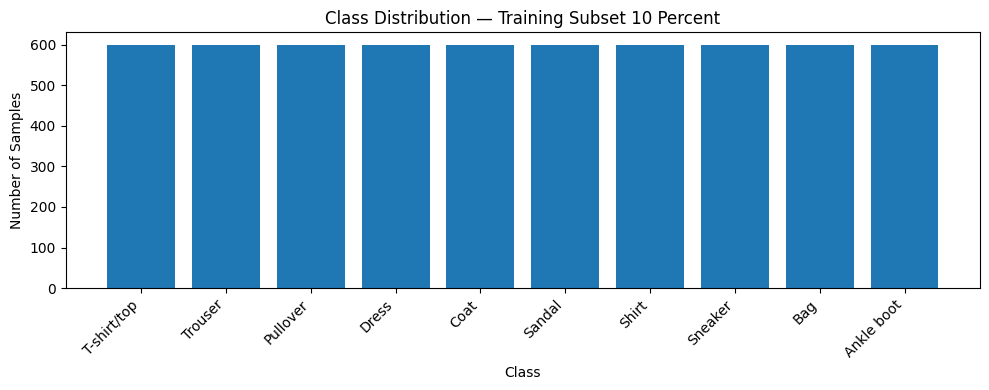

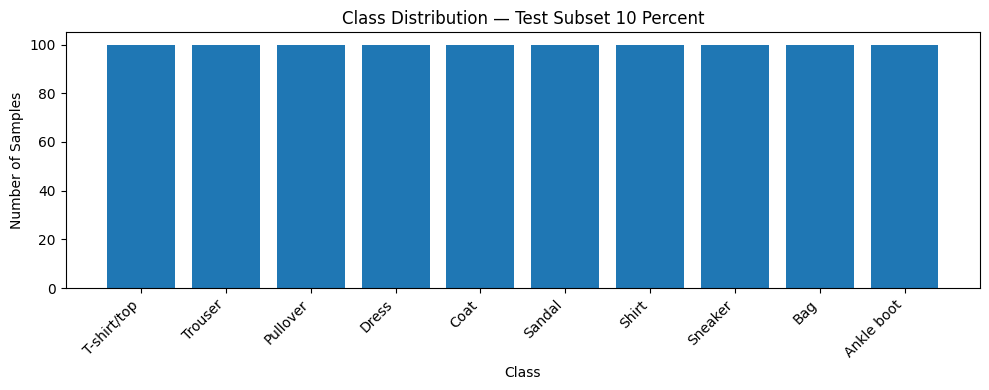

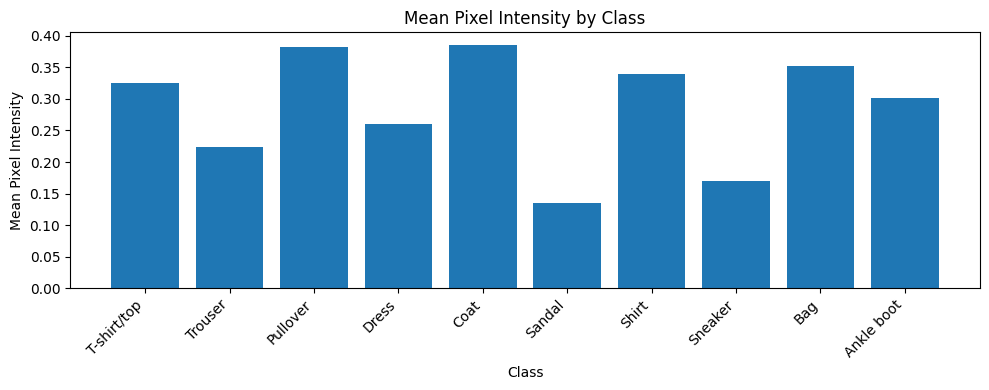

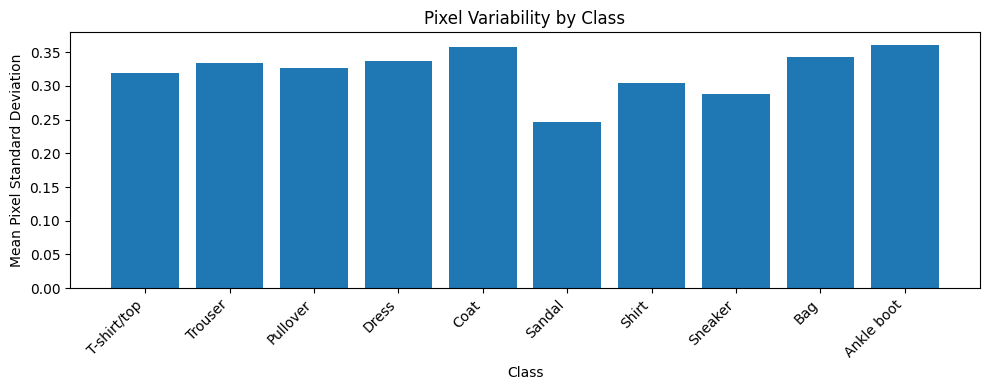

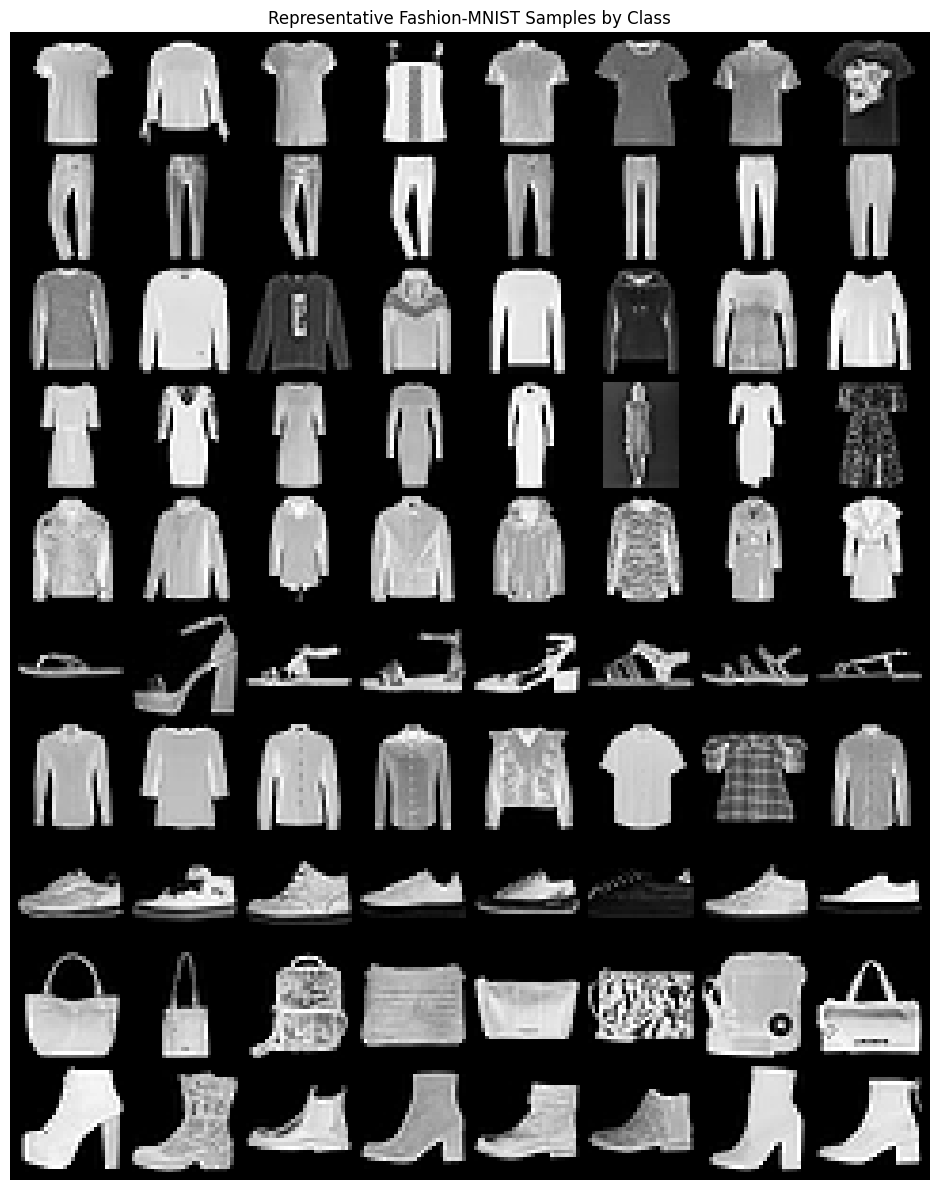

Output Title: EDA Insight Summary
- The selected training subset is class-balanced under the max/min <= 1.20 rule.
- No exact duplicate image hash was detected in the selected training subset.


In [5]:
# Cell 03 — EDA, Bias Audit, and Data Quality Insight
# Komentar akademik:
# EDA dilakukan untuk memahami distribusi label, intensitas piksel, variasi visual,
# serta kemungkinan duplikasi sederhana. Tujuannya bukan hanya eksplorasi,
# tetapi juga mencegah bias dan kesalahan logika sebelum model dilatih.

def label_distribution(dataset, split_name):
    labels = np.array(dataset.targets)
    counts = pd.Series(labels).value_counts().sort_index()
    df = pd.DataFrame({
        "split": split_name,
        "label": counts.index.astype(int),
        "class_name": [class_names[i] for i in counts.index],
        "count": counts.values.astype(int),
    })
    df["proportion"] = df["count"] / df["count"].sum()
    return df

def imbalance_audit(df):
    max_count = df["count"].max()
    min_count = df["count"].min()
    ratio = max_count / min_count
    status = "Balanced" if ratio <= 1.20 else "Potentially Imbalanced"
    return pd.DataFrame([{
        "max_count": int(max_count),
        "min_count": int(min_count),
        "imbalance_ratio": float(ratio),
        "status": status,
        "decision_rule": "Balanced if max/min <= 1.20"
    }])

def compute_image_stats(dataset):
    records = []
    for i in range(len(dataset)):
        img_tensor, label = dataset[i]
        arr = img_tensor.numpy()
        img_hash = hashlib.md5((arr * 255).astype(np.uint8).tobytes()).hexdigest()
        records.append({
            "index": i,
            "label": int(label),
            "class_name": class_names[int(label)],
            "mean_pixel": float(arr.mean()),
            "std_pixel": float(arr.std()),
            "nonzero_ratio": float((arr > 0).mean()),
            "hash": img_hash,
        })
    return pd.DataFrame(records)

train_dist = label_distribution(train_raw, "Training Subset 10 Percent")
test_dist = label_distribution(test_raw, "Test Subset 10 Percent")
dist_df = pd.concat([train_dist, test_dist], ignore_index=True)

train_imbalance_report = imbalance_audit(train_dist)
test_imbalance_report = imbalance_audit(test_dist)

stats_df = compute_image_stats(train_raw)
class_stats = stats_df.groupby(["label", "class_name"]).agg(
    n=("index", "count"),
    mean_pixel_mean=("mean_pixel", "mean"),
    mean_pixel_std=("mean_pixel", "std"),
    std_pixel_mean=("std_pixel", "mean"),
    nonzero_ratio_mean=("nonzero_ratio", "mean"),
).reset_index()

duplicate_count = stats_df.duplicated("hash").sum()
duplicate_report = pd.DataFrame([{
    "checked_samples": len(stats_df),
    "duplicate_hash_count": int(duplicate_count),
    "duplicate_ratio": float(duplicate_count / len(stats_df)),
    "interpretation": "Identical hash requires visual inspection; it is not automatically a data error."
}])

print("Output Title: Class Distribution Table")
display(dist_df)

print("Output Title: Imbalance Audit Summary")
display(pd.concat([
    train_imbalance_report.assign(split="Training"),
    test_imbalance_report.assign(split="Test")
]))

print("Output Title: Pixel Statistics by Class")
display(class_stats)

print("Output Title: Duplicate Hash Audit")
display(duplicate_report)

dist_df.to_csv(TABLE_DIR / "class_distribution.csv", index=False)
class_stats.to_csv(TABLE_DIR / "class_pixel_statistics.csv", index=False)
duplicate_report.to_csv(TABLE_DIR / "duplicate_hash_audit.csv", index=False)

for split_name, df in [
    ("Training Subset 10 Percent", train_dist),
    ("Test Subset 10 Percent", test_dist)
]:
    plt.figure(figsize=(10, 4))
    plt.bar(df["class_name"], df["count"])
    plt.title(f"Class Distribution — {split_name}")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"class_distribution_{split_name.replace(' ', '_').lower()}.png",
        dpi=200
    )
    plt.show()

plt.figure(figsize=(10, 4))
plt.bar(class_stats["class_name"], class_stats["mean_pixel_mean"])
plt.title("Mean Pixel Intensity by Class")
plt.xlabel("Class")
plt.ylabel("Mean Pixel Intensity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "mean_pixel_intensity_by_class.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(class_stats["class_name"], class_stats["std_pixel_mean"])
plt.title("Pixel Variability by Class")
plt.xlabel("Class")
plt.ylabel("Mean Pixel Standard Deviation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pixel_variability_by_class.png", dpi=200)
plt.show()

selected_indices = []
labels_train = np.array(train_raw.targets)
samples_per_class = 8

for cls in range(n_classes):
    cls_indices = np.where(labels_train == cls)[0][:samples_per_class]
    selected_indices.extend(cls_indices.tolist())

sample_images = torch.stack([train_raw[i][0] for i in selected_indices])
grid = make_grid(sample_images, nrow=samples_per_class, padding=2)

plt.figure(figsize=(samples_per_class * 1.3, n_classes * 1.2))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Representative Fashion-MNIST Samples by Class")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "representative_samples_by_class.png", dpi=200)
plt.show()

eda_insights = []

if float(train_imbalance_report["imbalance_ratio"].iloc[0]) <= 1.20:
    eda_insights.append(
        "The selected training subset is class-balanced under the max/min <= 1.20 rule."
    )
else:
    eda_insights.append(
        "The selected training subset shows potential class imbalance; sampler or class weighting is recommended."
    )

if duplicate_count == 0:
    eda_insights.append(
        "No exact duplicate image hash was detected in the selected training subset."
    )
else:
    eda_insights.append(
        "Exact duplicate hashes were detected; visual inspection is recommended before final reporting."
    )

print("Output Title: EDA Insight Summary")
for insight in eda_insights:
    print("-", insight)

pd.DataFrame({"eda_insight": eda_insights}).to_csv(
    TABLE_DIR / "eda_insights.csv",
    index=False
)

Output Title: Stratified Split Summary


,split,size
0,Training Split,5400
1,Validation Split,600
2,Test Subset,1000


Output Title: Balance Control Strategy


,strategy,reason,imbalance_ratio,threshold
0,Shuffle Only,The selected subset is already sufficiently ba...,1.0,1.2


Output Title: Stratified Split Distribution


,split,label,class_name,count,proportion
0,Training Split,0,T-shirt/top,540,0.1
1,Training Split,1,Trouser,540,0.1
2,Training Split,2,Pullover,540,0.1
3,Training Split,3,Dress,540,0.1
4,Training Split,4,Coat,540,0.1
5,Training Split,5,Sandal,540,0.1
6,Training Split,6,Shirt,540,0.1
7,Training Split,7,Sneaker,540,0.1
8,Training Split,8,Bag,540,0.1
9,Training Split,9,Ankle boot,540,0.1


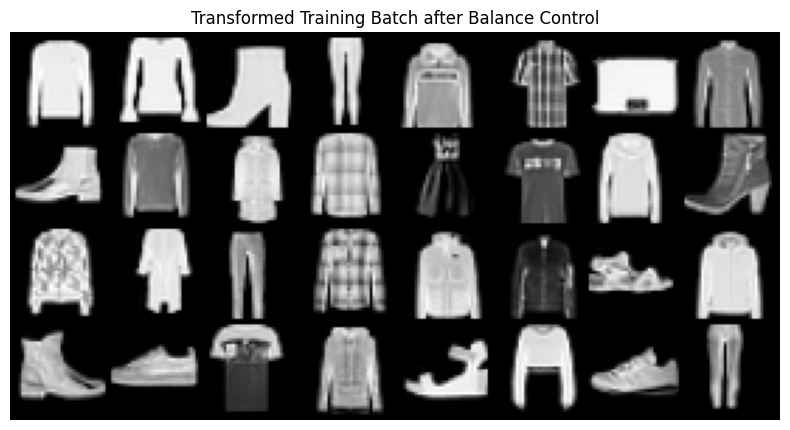

In [6]:
# Cell 04 — Preprocessing, Stratified Split, and Balance Control
# Komentar akademik:
# Transformasi dibuat konsisten untuk training dan evaluasi.
# Train-validation split dilakukan secara stratified dari subset 10%.
# WeightedRandomSampler hanya aktif jika ketidakseimbangan kelas terdeteksi.
# Tujuan cell ini adalah mencegah data leakage, menjaga proporsi kelas,
# serta menyiapkan DataLoader yang reproducible.

IMG_SIZE = 32
USE_LIGHT_AUGMENTATION = True

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=2) if USE_LIGHT_AUGMENTATION else transforms.Lambda(lambda x: x),
    transforms.RandomHorizontalFlip(p=0.25) if USE_LIGHT_AUGMENTATION else transforms.Lambda(lambda x: x),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

all_train_indices = np.arange(len(train_raw))
all_train_labels = np.array(train_raw.targets)

train_idx, val_idx = train_test_split(
    all_train_indices,
    test_size=0.10,
    random_state=SEED,
    stratify=all_train_labels
)

assert len(set(train_idx).intersection(set(val_idx))) == 0, (
    "Data leakage detected: train and validation overlap."
)

train10_dataset_aug = TransformableSubsetView(
    train_full_raw,
    train10_indices_full,
    transform=train_transform
)

train10_dataset_eval = TransformableSubsetView(
    train_full_raw,
    train10_indices_full,
    transform=eval_transform
)

test_dataset_eval = TransformableSubsetView(
    test_full_raw,
    test10_indices_full,
    transform=eval_transform
)

train_subset = Subset(train10_dataset_aug, train_idx)
val_subset = Subset(train10_dataset_eval, val_idx)

def make_weighted_sampler(indices, labels, imbalance_threshold=1.20):
    # Fungsi ini mengecek apakah data training masih seimbang.
    # Jika rasio max/min <= 1.20, cukup memakai shuffle biasa.
    # Jika rasio > 1.20, WeightedRandomSampler digunakan untuk mengurangi bias kelas.
    sub_labels = labels[indices]
    counts = pd.Series(sub_labels).value_counts().sort_index()
    imbalance_ratio = counts.max() / counts.min()

    if imbalance_ratio <= imbalance_threshold:
        return None, pd.DataFrame([{
            "strategy": "Shuffle Only",
            "reason": "The selected subset is already sufficiently balanced.",
            "imbalance_ratio": float(imbalance_ratio),
            "threshold": imbalance_threshold
        }])

    class_counts = counts.to_dict()
    sample_weights = np.array([
        1.0 / class_counts[int(label)]
        for label in sub_labels
    ])

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=GENERATOR
    )

    return sampler, pd.DataFrame([{
        "strategy": "Weighted Random Sampler",
        "reason": "Potential class imbalance was detected.",
        "imbalance_ratio": float(imbalance_ratio),
        "threshold": imbalance_threshold
    }])

sampler, balance_strategy = make_weighted_sampler(
    train_idx,
    all_train_labels
)

NUM_WORKERS = 2 if torch.cuda.is_available() else 0

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=(sampler is None),
    sampler=sampler,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker,
    generator=GENERATOR,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker,
    generator=GENERATOR,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    worker_init_fn=seed_worker,
    generator=GENERATOR,
    pin_memory=torch.cuda.is_available()
)

split_distribution = []

for split_name, indices in [
    ("Training Split", train_idx),
    ("Validation Split", val_idx)
]:
    labels = all_train_labels[indices]
    counts = pd.Series(labels).value_counts().sort_index()

    for label, count in counts.items():
        split_distribution.append({
            "split": split_name,
            "label": int(label),
            "class_name": class_names[int(label)],
            "count": int(count),
            "proportion": float(count / len(indices)),
        })

split_distribution_df = pd.DataFrame(split_distribution)

print("Output Title: Stratified Split Summary")
display(pd.DataFrame([
    {
        "split": "Training Split",
        "size": len(train_subset)
    },
    {
        "split": "Validation Split",
        "size": len(val_subset)
    },
    {
        "split": "Test Subset",
        "size": len(test_dataset_eval)
    },
]))

print("Output Title: Balance Control Strategy")
display(balance_strategy)

print("Output Title: Stratified Split Distribution")
display(split_distribution_df)

split_distribution_df.to_csv(
    TABLE_DIR / "stratified_split_distribution.csv",
    index=False
)

balance_strategy.to_csv(
    TABLE_DIR / "balance_control_strategy.csv",
    index=False
)

def denormalize(x):
    # Fungsi ini mengembalikan tensor dari rentang [-1, 1] ke [0, 1]
    # agar gambar dapat divisualisasikan dengan benar.
    return (x * 0.5 + 0.5).clamp(0, 1)

batch_images, batch_labels = next(iter(train_loader))
grid = make_grid(denormalize(batch_images[:32]), nrow=8, padding=2)

plt.figure(figsize=(8, 5))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Transformed Training Batch after Balance Control")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "transformed_training_batch.png",
    dpi=200
)
plt.show()

Output Title: Model Architecture Summary


,model,trainable_parameters
0,BaselineCNN,545098
1,RegularizedCNN,94762


Training model: BaselineCNN
Training model: RegularizedCNN
Output Title: Training History


,model,epoch,train_loss,train_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_macro_f1,learning_rate
0,BaselineCNN,1,1.193441,0.569074,0.567075,0.708980,0.755000,0.744325,0.0010
1,BaselineCNN,2,0.684973,0.741667,0.738318,0.621548,0.781667,0.773929,0.0010
2,BaselineCNN,3,0.615522,0.771296,0.767973,0.537811,0.813333,0.809036,0.0010
3,BaselineCNN,4,0.552857,0.795556,0.792695,0.515193,0.815000,0.807089,0.0010
4,BaselineCNN,5,0.518796,0.799074,0.796288,0.490830,0.846667,0.850100,0.0010
5,RegularizedCNN,1,1.602226,0.484815,0.472258,1.203690,0.695000,0.681567,0.0010
6,RegularizedCNN,2,1.110977,0.667037,0.659290,0.955184,0.731667,0.722415,0.0010
7,RegularizedCNN,3,0.887343,0.720741,0.711712,0.839560,0.735000,0.718079,0.0010
8,RegularizedCNN,4,0.783671,0.738889,0.732900,0.822499,0.686667,0.662107,0.0005
9,RegularizedCNN,5,0.704751,0.753704,0.747947,0.682439,0.768333,0.762953,0.0005


Output Title: Fit Diagnosis Summary


,model,last_train_macro_f1,last_validation_macro_f1,train_validation_gap,diagnosis,recommended_action
0,BaselineCNN,0.796288,0.850100,-0.053812,Acceptable Fit,Proceed to test evaluation and per-class bias ...
1,RegularizedCNN,0.747947,0.762953,-0.015006,Acceptable Fit,Proceed to test evaluation and per-class bias ...


Output Title: Best Model Selection


,best_model,best_epoch,selection_metric,best_validation_macro_f1,integrity_note
0,BaselineCNN,5,validation_macro_f1,0.8501,Best model is selected from executed training ...


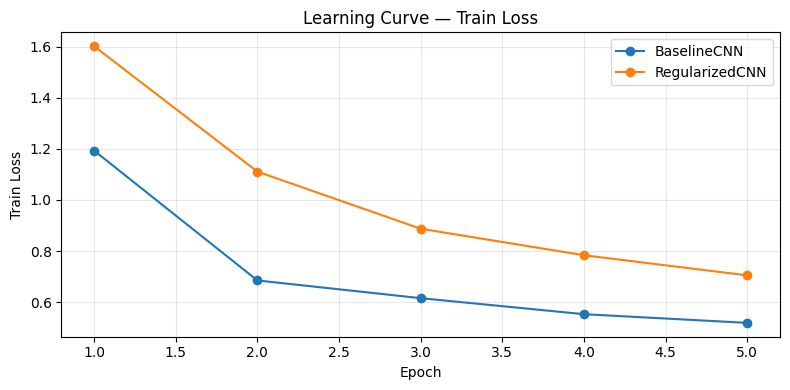

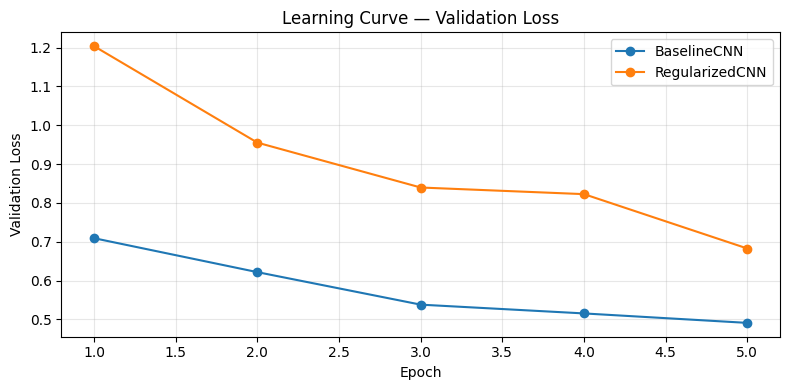

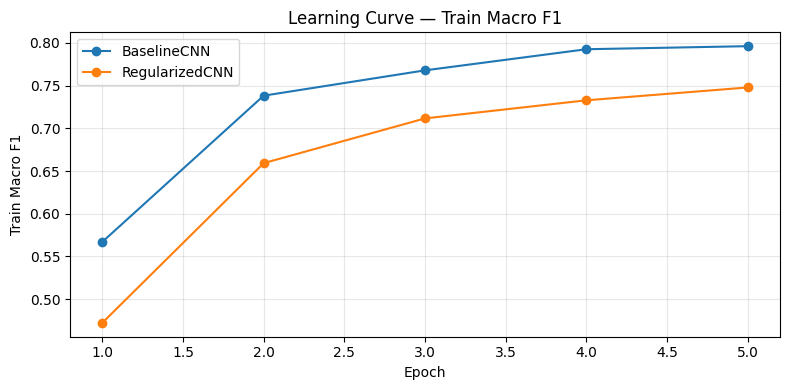

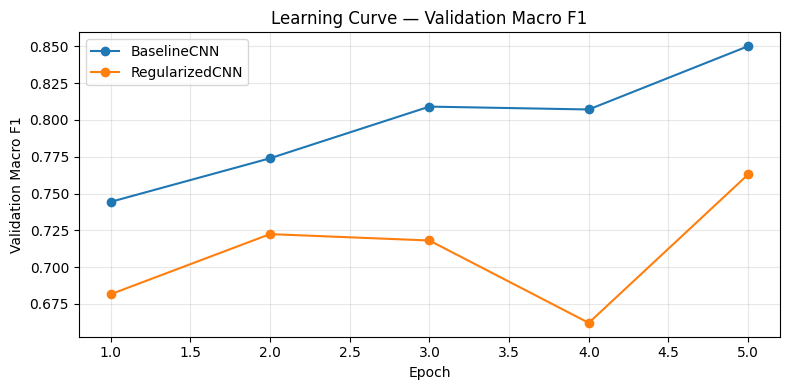

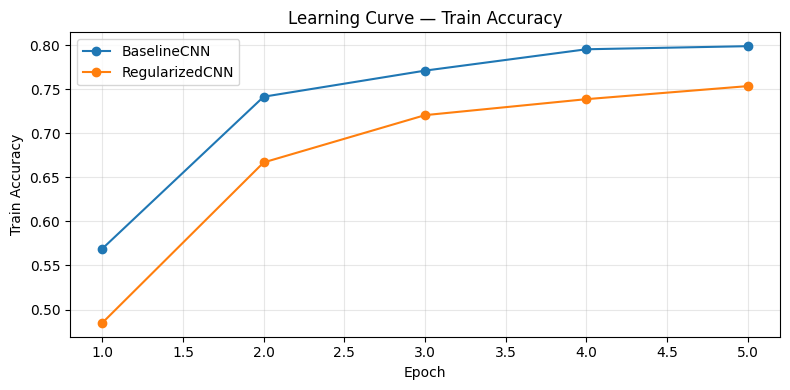

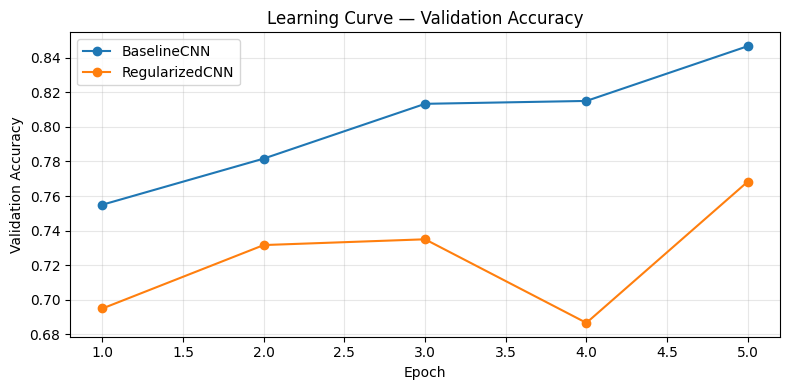

In [7]:
# Cell 05 — Model Development, Error Control, and Best Model Selection
# Komentar akademik:
# Dua model dibandingkan: BaselineCNN dan RegularizedCNN.
# RegularizedCNN memakai BatchNorm, Dropout, AdaptiveAvgPool, weight decay, scheduler, dan early stopping.
# Model terbaik dipilih berdasarkan validation macro-F1 untuk menjaga keseimbangan evaluasi antarkelas.
# Cell ini juga mendeteksi indikasi underfitting atau overfitting berdasarkan gap train-validation.

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class RegularizedCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.30):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


def build_model(model_name):
    # Fungsi ini memastikan model dapat dibangun ulang secara konsisten
    # pada tahap evaluasi, penyimpanan, dan deployment.
    if model_name == "BaselineCNN":
        return BaselineCNN(num_classes=n_classes)

    if model_name == "RegularizedCNN":
        return RegularizedCNN(num_classes=n_classes, dropout=0.30)

    raise ValueError(f"Unknown model name: {model_name}")


def count_parameters(model):
    # Menghitung jumlah parameter yang dapat dilatih.
    # Informasi ini penting untuk membandingkan kompleksitas model.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def run_epoch(model, loader, criterion, optimizer=None):
    # Fungsi ini digunakan untuk training dan validation.
    # Jika optimizer diberikan, mode training aktif.
    # Jika optimizer None, mode evaluasi aktif.
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()

                # Gradient clipping digunakan untuk mencegah gradient meledak.
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

                optimizer.step()

            total_loss += loss.item() * x.size(0)

            preds = logits.argmax(1).detach().cpu().numpy()
            targets = y.detach().cpu().numpy()

            all_preds.extend(preds.tolist())
            all_targets.extend(targets.tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, macro_f1


def train_model(
    model,
    model_name,
    epochs=5,
    lr=1e-3,
    weight_decay=1e-4,
    patience=3
):
    # Fungsi ini melatih model dengan early stopping berbasis validation macro-F1.
    # Pemilihan validation macro-F1 membantu menghindari bias terhadap satu kelas dominan.
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1
    )

    best_state = None
    best_val_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc, val_f1 = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None
        )

        scheduler.step(val_f1)

        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "train_macro_f1": train_f1,
            "validation_loss": val_loss,
            "validation_accuracy": val_acc,
            "validation_macro_f1": val_f1,
            "learning_rate": optimizer.param_groups[0]["lr"],
        }

        history.append(row)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping activated for {model_name} at epoch {epoch}.")
            break

    if best_state is None:
        raise RuntimeError(
            f"No best state was saved for {model_name}. "
            "Please check training loop and validation metric."
        )

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def diagnose_fit(history_df, model_name):
    # Diagnosis ini bersifat heuristik.
    # Tujuannya memberikan sinyal awal apakah model underfitting, overfitting, atau cukup stabil.
    last = history_df[history_df["model"] == model_name].iloc[-1]

    train_f1 = last["train_macro_f1"]
    val_f1 = last["validation_macro_f1"]
    gap = train_f1 - val_f1

    if train_f1 < 0.70 and val_f1 < 0.70:
        diagnosis = "Underfitting"
        action = "Increase epochs, model capacity, or adjust learning rate."

    elif gap > 0.08 and train_f1 > 0.85:
        diagnosis = "Overfitting"
        action = "Strengthen regularization, augmentation, early stopping, or reduce capacity."

    else:
        diagnosis = "Acceptable Fit"
        action = "Proceed to test evaluation and per-class bias audit."

    return {
        "model": model_name,
        "last_train_macro_f1": float(train_f1),
        "last_validation_macro_f1": float(val_f1),
        "train_validation_gap": float(gap),
        "diagnosis": diagnosis,
        "recommended_action": action,
    }


model_specs = pd.DataFrame([
    {
        "model": "BaselineCNN",
        "trainable_parameters": count_parameters(BaselineCNN(num_classes=n_classes))
    },
    {
        "model": "RegularizedCNN",
        "trainable_parameters": count_parameters(RegularizedCNN(num_classes=n_classes))
    },
])

print("Output Title: Model Architecture Summary")
display(model_specs)

model_specs.to_csv(
    TABLE_DIR / "model_architecture_summary.csv",
    index=False
)

if RUN_TRAINING:
    all_histories = []
    trained_models = {}

    for model_name in ["BaselineCNN", "RegularizedCNN"]:
        print(f"Training model: {model_name}")

        set_global_seed(SEED)

        model = build_model(model_name)

        trained_model, history = train_model(
            model=model,
            model_name=model_name,
            epochs=EPOCHS
        )

        all_histories.append(history)
        trained_models[model_name] = trained_model

    history_df = pd.concat(all_histories, ignore_index=True)

    best_row = history_df.sort_values(
        "validation_macro_f1",
        ascending=False
    ).iloc[0]

    best_model_name = str(best_row["model"])
    best_model = trained_models[best_model_name]

    fit_diagnosis_df = pd.DataFrame([
        diagnose_fit(history_df, model_name)
        for model_name in history_df["model"].unique()
    ])

    best_model_summary = pd.DataFrame([{
        "best_model": best_model_name,
        "best_epoch": int(best_row["epoch"]),
        "selection_metric": "validation_macro_f1",
        "best_validation_macro_f1": float(best_row["validation_macro_f1"]),
        "integrity_note": (
            "Best model is selected from executed training results, "
            "not manual claims."
        )
    }])

    print("Output Title: Training History")
    display(history_df)

    print("Output Title: Fit Diagnosis Summary")
    display(fit_diagnosis_df)

    print("Output Title: Best Model Selection")
    display(best_model_summary)

    history_df.to_csv(
        TABLE_DIR / "training_history.csv",
        index=False
    )

    fit_diagnosis_df.to_csv(
        TABLE_DIR / "fit_diagnosis_summary.csv",
        index=False
    )

    best_model_summary.to_csv(
        TABLE_DIR / "best_model_selection.csv",
        index=False
    )

    for metric in [
        "train_loss",
        "validation_loss",
        "train_macro_f1",
        "validation_macro_f1",
        "train_accuracy",
        "validation_accuracy"
    ]:
        plt.figure(figsize=(8, 4))

        for model_name in history_df["model"].unique():
            subset = history_df[history_df["model"] == model_name]
            plt.plot(
                subset["epoch"],
                subset[metric],
                marker="o",
                label=model_name
            )

        plt.title(f"Learning Curve — {metric.replace('_', ' ').title()}")
        plt.xlabel("Epoch")
        plt.ylabel(metric.replace("_", " ").title())
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plt.savefig(
            FIGURE_DIR / f"learning_curve_{metric}.png",
            dpi=200
        )

        plt.show()

else:
    history_df = pd.DataFrame()
    best_model = None
    best_model_name = None

    print("Output Title: Training Skipped")
    print("RUN_TRAINING=False; no model performance is reported.")

Output Title: Test Performance Summary


,best_model,test_accuracy,test_macro_f1,lowest_f1_class,lowest_f1_value,integrity_note
0,BaselineCNN,0.817,0.819535,Shirt,0.516129,Metrics are computed from executed inference o...


Output Title: Classification Report


,precision,recall,f1-score,support
T-shirt/top,0.813187,0.740,0.774869,100.000
Trouser,0.979592,0.960,0.969697,100.000
Pullover,0.804598,0.700,0.748663,100.000
Dress,0.794118,0.810,0.801980,100.000
Coat,0.701923,0.730,0.715686,100.000
Sandal,0.989011,0.900,0.942408,100.000
Shirt,0.478632,0.560,0.516129,100.000
Sneaker,0.837838,0.930,0.881517,100.000
Bag,0.921569,0.940,0.930693,100.000
Ankle boot,0.927835,0.900,0.913706,100.000


Output Title: Per-Class Bias Evaluation


,label,class_name,precision,recall,f1_score,support
0,0,T-shirt/top,0.813187,0.74,0.774869,100
1,1,Trouser,0.979592,0.96,0.969697,100
2,2,Pullover,0.804598,0.70,0.748663,100
3,3,Dress,0.794118,0.81,0.801980,100
4,4,Coat,0.701923,0.73,0.715686,100
5,5,Sandal,0.989011,0.90,0.942408,100
6,6,Shirt,0.478632,0.56,0.516129,100
7,7,Sneaker,0.837838,0.93,0.881517,100
8,8,Bag,0.921569,0.94,0.930693,100
9,9,Ankle boot,0.927835,0.90,0.913706,100


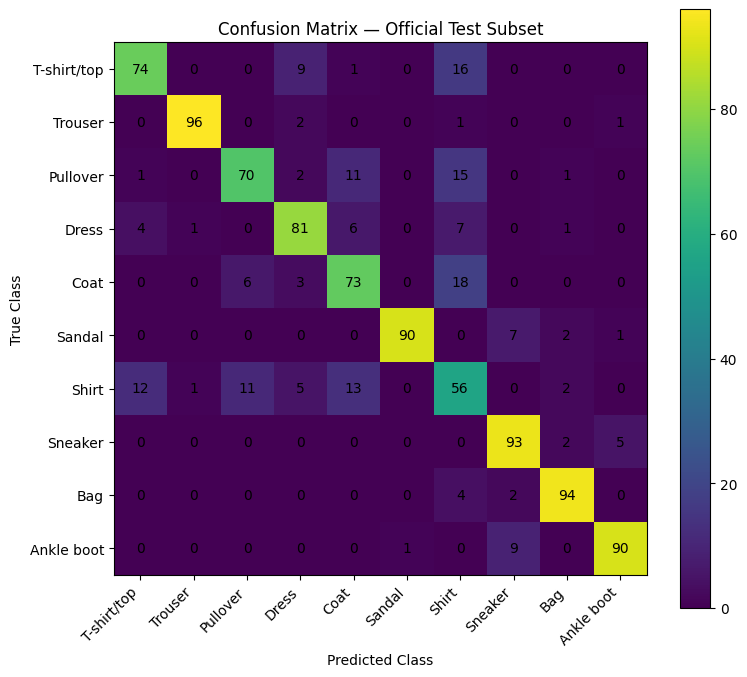

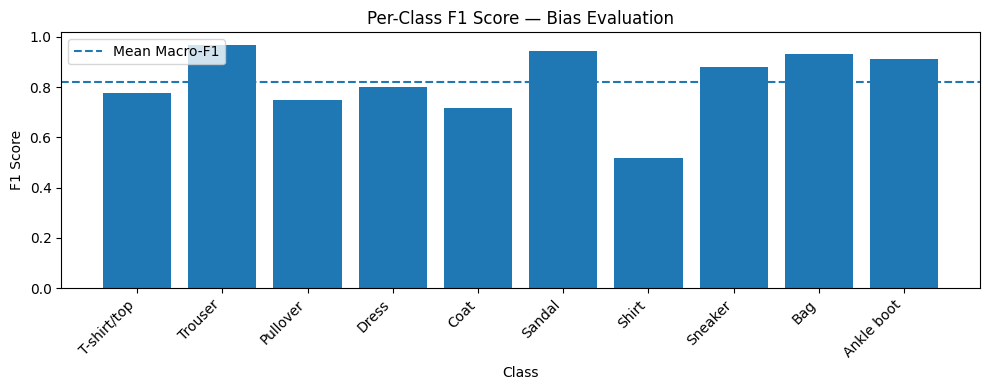

Output Title: Simple Development Testing with Seven New Samples


,sample_id,source,image_path,true_label,true_class,predicted_label,predicted_class,confidence,correct
0,0,official_test_subset_not_used_in_training,/content/fmnist_stylegan_research_project/new_...,5,Sandal,5,Sandal,0.851311,1
1,1,official_test_subset_not_used_in_training,/content/fmnist_stylegan_research_project/new_...,2,Pullover,2,Pullover,0.519629,1
2,2,official_test_subset_not_used_in_training,/content/fmnist_stylegan_research_project/new_...,5,Sandal,5,Sandal,0.983030,1
3,3,official_test_subset_not_used_in_training,/content/fmnist_stylegan_research_project/new_...,6,Shirt,6,Shirt,0.471327,1
4,4,official_test_subset_not_used_in_training,/content/fmnist_stylegan_research_project/new_...,3,Dress,3,Dress,0.736816,1
5,5,official_test_subset_not_used_in_training,/content/fmnist_stylegan_research_project/new_...,2,Pullover,0,T-shirt/top,0.556660,0
6,6,official_test_subset_not_used_in_training,/content/fmnist_stylegan_research_project/new_...,5,Sandal,7,Sneaker,0.555406,0


Output Title: Simple Development Testing Summary


,n_new_samples,simple_test_accuracy,interpretation
0,7,0.714286,"This is a development sanity check, not the pr..."


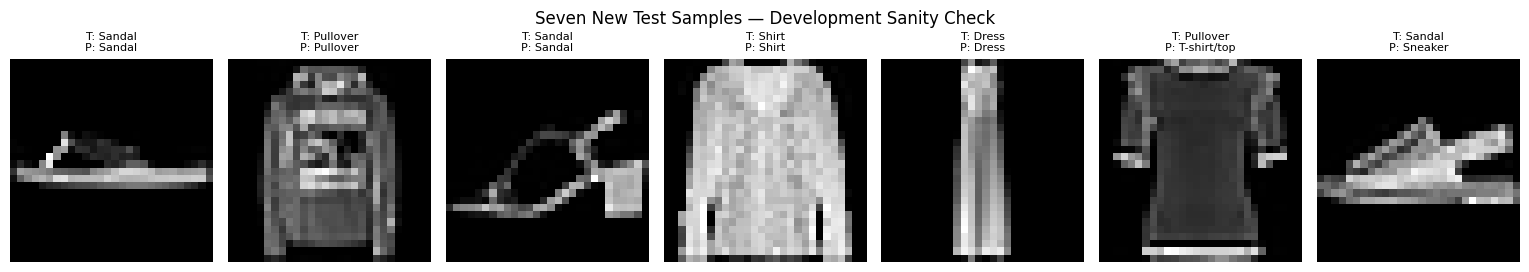

Output Title: Informative Evaluation Insight
- The selected best model is BaselineCNN.
- The lowest F1-score appears in class: Shirt.
- Inspect the confusion matrix to identify systematic class confusion.


In [8]:
# Cell 06 — Model Evaluation, Simple New Data Testing, and Error Insight
# Komentar akademik:
# Evaluasi akhir memakai official test subset yang tidak digunakan pada training atau validation.
# Pengujian sederhana dilakukan pada 7 data baru dari official test subset untuk simulasi tahap development.
# Macro-F1 dan per-class F1 diprioritaskan karena lebih informatif untuk data multi-kelas.
# Cell ini tidak melakukan training ulang; cell ini hanya menguji model terbaik yang dipilih di Cell 05.

def predict_model(model, loader):
    # Fungsi ini melakukan prediksi batch pada test_loader.
    # torch.no_grad() digunakan karena tahap evaluasi tidak membutuhkan gradient.
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)

            logits = model(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)

            all_probs.append(probs)
            all_preds.extend(preds.tolist())
            all_targets.extend(y.numpy().tolist())

    return np.array(all_targets), np.array(all_preds), np.vstack(all_probs)


def predict_single_pil(model, image_pil):
    # Fungsi ini dipakai untuk pengujian satu gambar.
    # Input berupa PIL image agar alur ini konsisten dengan dashboard Streamlit.
    model.eval()

    x = eval_transform(image_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    return pred_idx, pred_class, confidence, probs


if best_model is not None:
    y_true, y_pred, y_prob = predict_model(best_model, test_loader)

    test_accuracy = accuracy_score(y_true, y_pred)
    test_macro_f1 = f1_score(y_true, y_pred, average="macro")

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(n_classes)),
        zero_division=0
    )

    per_class_eval = pd.DataFrame({
        "label": list(range(n_classes)),
        "class_name": class_names,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "support": support,
    })

    worst_class = per_class_eval.sort_values("f1_score").iloc[0]

    test_summary = pd.DataFrame([{
        "best_model": best_model_name,
        "test_accuracy": float(test_accuracy),
        "test_macro_f1": float(test_macro_f1),
        "lowest_f1_class": worst_class["class_name"],
        "lowest_f1_value": float(worst_class["f1_score"]),
        "integrity_note": (
            "Metrics are computed from executed inference on official test subset."
        )
    }])

    print("Output Title: Test Performance Summary")
    display(test_summary)

    print("Output Title: Classification Report")
    display(report_df)

    print("Output Title: Per-Class Bias Evaluation")
    display(per_class_eval)

    test_summary.to_csv(
        TABLE_DIR / "test_performance_summary.csv",
        index=False
    )

    report_df.to_csv(
        TABLE_DIR / "classification_report.csv"
    )

    per_class_eval.to_csv(
        TABLE_DIR / "per_class_bias_evaluation.csv",
        index=False
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(n_classes))
    )

    cm_df = pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    )

    cm_df.to_csv(
        TABLE_DIR / "confusion_matrix.csv"
    )

    plt.figure(figsize=(8, 7))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix — Official Test Subset")
    plt.colorbar()

    tick_marks = np.arange(n_classes)

    plt.xticks(
        tick_marks,
        class_names,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        tick_marks,
        class_names
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")

    for i in range(n_classes):
        for j in range(n_classes):
            plt.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center"
            )

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "confusion_matrix_official_test_subset.png",
        dpi=200
    )

    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(
        per_class_eval["class_name"],
        per_class_eval["f1_score"]
    )

    plt.axhline(
        per_class_eval["f1_score"].mean(),
        linestyle="--",
        label="Mean Macro-F1"
    )

    plt.title("Per-Class F1 Score — Bias Evaluation")
    plt.xlabel("Class")
    plt.ylabel("F1 Score")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "per_class_f1_bias_evaluation.png",
        dpi=200
    )

    plt.show()

    # Pengujian sederhana dengan 7 data baru.
    # Data diambil dari official test subset, sehingga tidak digunakan pada training atau validation.
    rng = np.random.default_rng(SEED)

    new_sample_indices = rng.choice(
        len(test_raw),
        size=N_NEW_TEST_SAMPLES,
        replace=False
    )

    simple_test_records = []
    to_pil = transforms.ToPILImage()

    for local_i, idx in enumerate(new_sample_indices):
        img_tensor, true_label = test_raw[int(idx)]

        img_pil = to_pil(img_tensor).convert("RGB")

        safe_class_name = class_names[int(true_label)].replace("/", "_")

        image_path = (
            SAMPLE_DIR /
            f"new_sample_{local_i:02d}_true_{safe_class_name}.png"
        )

        img_pil.save(image_path)

        pred_idx, pred_class, confidence, probs = predict_single_pil(
            best_model,
            img_pil
        )

        simple_test_records.append({
            "sample_id": local_i,
            "source": "official_test_subset_not_used_in_training",
            "image_path": str(image_path),
            "true_label": int(true_label),
            "true_class": class_names[int(true_label)],
            "predicted_label": pred_idx,
            "predicted_class": pred_class,
            "confidence": confidence,
            "correct": int(pred_idx == int(true_label)),
        })

    simple_test_df = pd.DataFrame(simple_test_records)
    simple_test_accuracy = simple_test_df["correct"].mean()

    print("Output Title: Simple Development Testing with Seven New Samples")
    display(simple_test_df)

    print("Output Title: Simple Development Testing Summary")
    display(pd.DataFrame([{
        "n_new_samples": N_NEW_TEST_SAMPLES,
        "simple_test_accuracy": float(simple_test_accuracy),
        "interpretation": (
            "This is a development sanity check, "
            "not the primary statistical evaluation."
        )
    }]))

    simple_test_df.to_csv(
        TABLE_DIR / "simple_development_testing_7_samples.csv",
        index=False
    )

    # Visualisasi 7 data baru.
    fig, axes = plt.subplots(
        1,
        N_NEW_TEST_SAMPLES,
        figsize=(N_NEW_TEST_SAMPLES * 2.2, 2.8)
    )

    if N_NEW_TEST_SAMPLES == 1:
        axes = [axes]

    for ax, row in zip(axes, simple_test_records):
        img = Image.open(row["image_path"]).convert("RGB")

        ax.imshow(img)
        ax.axis("off")

        title = (
            f"T: {row['true_class']}\n"
            f"P: {row['predicted_class']}"
        )

        ax.set_title(title, fontsize=8)

    plt.suptitle("Seven New Test Samples — Development Sanity Check")
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "seven_new_test_samples_prediction.png",
        dpi=200
    )

    plt.show()

    print("Output Title: Informative Evaluation Insight")
    print(f"- The selected best model is {best_model_name}.")
    print(f"- The lowest F1-score appears in class: {worst_class['class_name']}.")
    print("- Inspect the confusion matrix to identify systematic class confusion.")

else:
    print("Output Title: Evaluation Not Available")
    print(
        "No trained model is available. "
        "Execute the model development cell with RUN_TRAINING=True."
    )

In [9]:
# Cell 07 — Model Persistence with PyTorch Checkpoint and Joblib Bundle
# Komentar akademik:
# Untuk model PyTorch, penyimpanan state_dict `.pt` tetap menjadi format utama.
# Sesuai kebutuhan deployment, dibuat juga bundle `.joblib` berisi state_dict CPU, metadata,
# konfigurasi transformasi, dan daftar kelas. Joblib hanya boleh dimuat dari file tepercaya.
# Cell ini juga melakukan validasi load ulang untuk memastikan file model tidak rusak.

if best_model is None:
    raise RuntimeError(
        "Best model is not available. "
        "Train and evaluate the model before saving."
    )

# Model dipindahkan ke CPU sebelum disimpan agar lebih portabel untuk deployment.
best_model_cpu = best_model.to("cpu")
best_model_cpu.eval()

pytorch_checkpoint_path = MODEL_DIR / "best_classifier_checkpoint.pt"
joblib_bundle_path = MODEL_DIR / "best_classifier_bundle.joblib"

checkpoint = {
    "model_name": best_model_name,
    "model_state_dict": best_model_cpu.state_dict(),
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "seed": SEED,
    "data_fraction": DATA_FRACTION,
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
    "integrity_note": (
        "This checkpoint stores the model state_dict and metadata. "
        "Metrics are included only if produced by executed evaluation cells."
    )
}

torch.save(
    checkpoint,
    pytorch_checkpoint_path
)

joblib_bundle = {
    "model_name": best_model_name,
    "model_state_dict": {
        k: v.cpu()
        for k, v in best_model_cpu.state_dict().items()
    },
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "normalization_mean": [0.5, 0.5, 0.5],
    "normalization_std": [0.5, 0.5, 0.5],
    "metadata": {
        "seed": SEED,
        "data_fraction": DATA_FRACTION,
        "test_accuracy": float(test_accuracy),
        "test_macro_f1": float(test_macro_f1),
        "created_at": datetime.now().isoformat(),
        "warning": (
            "Load this joblib file only from a trusted source. "
            "Joblib uses pickle-based persistence."
        )
    }
}

joblib.dump(
    joblib_bundle,
    joblib_bundle_path
)

# Validasi load ulang joblib agar file deployment tidak rusak.
loaded_bundle = joblib.load(joblib_bundle_path)

loaded_model = build_model(
    loaded_bundle["model_name"]
)

loaded_model.load_state_dict(
    loaded_bundle["model_state_dict"]
)

loaded_model.eval()

print("Output Title: Model Persistence Summary")

model_persistence_summary = pd.DataFrame([{
    "pytorch_checkpoint": str(pytorch_checkpoint_path),
    "joblib_bundle": str(joblib_bundle_path),
    "joblib_load_test": "Success",
    "saved_model_name": loaded_bundle["model_name"],
    "saved_classes": len(loaded_bundle["class_names"]),
    "integrity_note": (
        "Both .pt and .joblib files are stored in the project models folder."
    )
}])

display(model_persistence_summary)

model_persistence_summary.to_csv(
    TABLE_DIR / "model_persistence_summary.csv",
    index=False
)

# Kembalikan model terbaik ke device awal jika masih diperlukan pada cell berikutnya.
best_model = best_model_cpu.to(DEVICE)

Output Title: Model Persistence Summary


,pytorch_checkpoint,joblib_bundle,joblib_load_test,saved_model_name,saved_classes,integrity_note
0,/content/fmnist_stylegan_research_project/mode...,/content/fmnist_stylegan_research_project/mode...,Success,BaselineCNN,10,Both .pt and .joblib files are stored in the p...


In [10]:
# Cell 08 — StyleGAN2-ADA Dataset Export and Conditional Training Preparation
# Komentar akademik:
# Cell ini menyiapkan data untuk tahap generatif StyleGAN2-ADA.
# Export hanya memakai training subset 10% untuk mengurangi beban komputasi.
# Test subset tidak diekspor agar tidak terjadi data leakage.
# RGB di sini adalah duplikasi kanal grayscale, bukan informasi warna baru.
# Full StyleGAN2-ADA training tidak dijalankan otomatis karena membutuhkan GPU dan waktu komputasi besar.

STYLEGAN_IMG_DIR = STYLEGAN_DIR_OUT / "images"
STYLEGAN_ZIP_PATH = STYLEGAN_DIR_OUT / "fmnist32_stylegan2ada_10pct.zip"

if STYLEGAN_IMG_DIR.exists():
    shutil.rmtree(STYLEGAN_IMG_DIR)

STYLEGAN_IMG_DIR.mkdir(parents=True, exist_ok=True)

to_pil = transforms.ToPILImage()
resize_to_32 = transforms.Resize((32, 32))

labels_for_json = []

for idx in range(len(train_raw)):
    img_tensor, label = train_raw[idx]

    # Gambar Fashion-MNIST asli adalah grayscale 28×28.
    # Resize ke 32×32 dilakukan agar lebih sesuai dengan pipeline resolusi power-of-two.
    # convert("RGB") hanya menduplikasi kanal grayscale menjadi 3 kanal.
    img = to_pil(img_tensor)
    img = resize_to_32(img).convert("RGB")

    fname = f"{idx:08d}.png"

    img.save(STYLEGAN_IMG_DIR / fname)

    labels_for_json.append([
        fname,
        int(label)
    ])

dataset_json_path = STYLEGAN_IMG_DIR / "dataset.json"

with open(dataset_json_path, "w", encoding="utf-8") as f:
    json.dump(
        {"labels": labels_for_json},
        f
    )

if STYLEGAN_ZIP_PATH.exists():
    STYLEGAN_ZIP_PATH.unlink()

with zipfile.ZipFile(
    STYLEGAN_ZIP_PATH,
    "w",
    compression=zipfile.ZIP_STORED
) as zf:
    for file in STYLEGAN_IMG_DIR.rglob("*"):
        zf.write(
            file,
            arcname=file.relative_to(STYLEGAN_IMG_DIR)
        )

with zipfile.ZipFile(STYLEGAN_ZIP_PATH, "r") as zf:
    names = zf.namelist()

    zip_validation = {
        "zip_exists": STYLEGAN_ZIP_PATH.exists(),
        "has_dataset_json": "dataset.json" in names,
        "png_count": sum(name.endswith(".png") for name in names),
        "expected_png_count": len(labels_for_json),
    }

    zip_validation["valid"] = (
        zip_validation["zip_exists"]
        and zip_validation["has_dataset_json"]
        and zip_validation["png_count"] == zip_validation["expected_png_count"]
    )

print("Output Title: StyleGAN2-ADA Dataset Export Summary")

stylegan_export_summary = pd.DataFrame([{
    "exported_images": len(labels_for_json),
    "source": "Training Subset 10 Percent",
    "image_size": "32x32",
    "channels": "RGB duplicated from grayscale",
    "label_file": "dataset.json",
    "zip_path": str(STYLEGAN_ZIP_PATH),
    "data_leakage_control": "Only training subset is exported."
}])

display(stylegan_export_summary)

print("Output Title: StyleGAN2-ADA ZIP Validation")
display(pd.DataFrame([zip_validation]))

stylegan_export_summary.to_csv(
    TABLE_DIR / "stylegan2ada_dataset_export_summary.csv",
    index=False
)

pd.DataFrame([zip_validation]).to_csv(
    TABLE_DIR / "stylegan2ada_zip_validation.csv",
    index=False
)

if not zip_validation["valid"]:
    raise ValueError("StyleGAN2-ADA ZIP validation failed.")

STYLEGAN_REPO_DIR = PROJECT_DIR / "stylegan2-ada-pytorch"
RUN_CLONE_STYLEGAN = True

if RUN_CLONE_STYLEGAN and not STYLEGAN_REPO_DIR.exists():
    subprocess.run([
        "git",
        "clone",
        "https://github.com/NVlabs/stylegan2-ada-pytorch.git",
        str(STYLEGAN_REPO_DIR)
    ], check=True)

train_py = STYLEGAN_REPO_DIR / "train.py"

STYLEGAN_OUTDIR = PROJECT_DIR / "stylegan2ada_training_runs"
STYLEGAN_OUTDIR.mkdir(parents=True, exist_ok=True)

STYLEGAN_KIMG = 100
STYLEGAN_CFG = "cifar"
STYLEGAN_MIRROR = 0

stylegan_command = [
    "python",
    str(train_py),
    "--outdir",
    str(STYLEGAN_OUTDIR),
    "--data",
    str(STYLEGAN_ZIP_PATH),
    "--gpus",
    "1",
    "--cfg",
    STYLEGAN_CFG,
    "--cond",
    "1",
    "--mirror",
    str(STYLEGAN_MIRROR),
    "--snap",
    "10",
    "--kimg",
    str(STYLEGAN_KIMG),
    "--seed",
    str(SEED),
]

stylegan_command_report = pd.DataFrame([{
    "training_type": "Conditional StyleGAN2-ADA",
    "configuration": STYLEGAN_CFG,
    "conditional_flag": "--cond=1",
    "mirror": STYLEGAN_MIRROR,
    "kimg": STYLEGAN_KIMG,
    "command": " ".join(stylegan_command),
    "integrity_note": (
        "This is a command template; full GAN training is not executed automatically."
    )
}])

print("Output Title: Conditional StyleGAN2-ADA Training Command")
display(stylegan_command_report)

stylegan_command_report.to_csv(
    TABLE_DIR / "stylegan2ada_training_command.csv",
    index=False
)

RUN_STYLEGAN_TRAINING = False

if RUN_STYLEGAN_TRAINING:
    assert torch.cuda.is_available(), (
        "GPU is required for StyleGAN2-ADA training."
    )

    subprocess.run(
        stylegan_command,
        check=True
    )

else:
    print("Output Title: StyleGAN2-ADA Training Status")
    print(
        "Training command is prepared, but RUN_STYLEGAN_TRAINING=False. "
        "No GAN result is claimed."
    )

Output Title: StyleGAN2-ADA Dataset Export Summary


,exported_images,source,image_size,channels,label_file,zip_path,data_leakage_control
0,6000,Training Subset 10 Percent,32x32,RGB duplicated from grayscale,dataset.json,/content/fmnist_stylegan_research_project/styl...,Only training subset is exported.


Output Title: StyleGAN2-ADA ZIP Validation


,zip_exists,has_dataset_json,png_count,expected_png_count,valid
0,True,True,6000,6000,True


Output Title: Conditional StyleGAN2-ADA Training Command


,training_type,configuration,conditional_flag,mirror,kimg,command,integrity_note
0,Conditional StyleGAN2-ADA,cifar,--cond=1,0,100,python /content/fmnist_stylegan_research_proje...,This is a command template; full GAN training ...


Output Title: StyleGAN2-ADA Training Status
Training command is prepared, but RUN_STYLEGAN_TRAINING=False. No GAN result is claimed.


In [11]:
# Cell 09 — Streamlit Application File for Interactive Dashboard
# Komentar akademik:
# Cell ini membuat file aplikasi Streamlit di dalam folder proyek.
# Aplikasi memuat model `.joblib`, menerima upload gambar, dan menampilkan prediksi.
# Model yang digunakan adalah classifier evaluator Fashion-MNIST, bukan model generatif StyleGAN2-ADA.
# Catatan metodologis: model dilatih pada Fashion-MNIST, sehingga prediksi paling valid
# untuk gambar bergaya Fashion-MNIST, bukan foto fashion real-world resolusi tinggi.

app_py_path = APP_DIR / "app.py"
model_path_for_app = joblib_bundle_path

app_code = f'''
import joblib
import numpy as np
import pandas as pd
from PIL import Image

import streamlit as st

import torch
import torch.nn as nn
from torchvision import transforms


class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class RegularizedCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.30):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


def build_model(model_name, num_classes):
    if model_name == "BaselineCNN":
        return BaselineCNN(num_classes=num_classes)

    if model_name == "RegularizedCNN":
        return RegularizedCNN(num_classes=num_classes)

    raise ValueError(f"Unknown model name: {{model_name}}")


@st.cache_resource
def load_bundle():
    # Bundle joblib hanya boleh dimuat dari file yang dibuat sendiri dan tepercaya.
    # File ini berasal dari Cell 07.
    bundle = joblib.load(r"{model_path_for_app}")

    class_names = bundle["class_names"]

    model = build_model(
        bundle["model_name"],
        len(class_names)
    )

    model.load_state_dict(
        bundle["model_state_dict"]
    )

    model.eval()

    return model, bundle


def preprocess_image(image, img_size, mean, std):
    # Preprocessing harus konsisten dengan training.
    # Gambar diubah ke 32x32, dikonversi ke 3 channel, lalu dinormalisasi.
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return transform(image).unsqueeze(0)


st.set_page_config(
    page_title="Fashion-MNIST Classifier Dashboard",
    page_icon="👕",
    layout="wide"
)

st.title("Fashion-MNIST Classifier Dashboard")

st.caption(
    "Interactive deployment prototype for a bias-controlled and reproducible "
    "Fashion-MNIST classifier."
)

model, bundle = load_bundle()
class_names = bundle["class_names"]

st.sidebar.header("Model Metadata")
st.sidebar.write("Model:", bundle["model_name"])
st.sidebar.write("Classes:", len(class_names))
st.sidebar.write("Data fraction:", bundle["metadata"].get("data_fraction"))
st.sidebar.write(
    "Test accuracy:",
    round(bundle["metadata"].get("test_accuracy", 0.0), 4)
)
st.sidebar.write(
    "Test macro-F1:",
    round(bundle["metadata"].get("test_macro_f1", 0.0), 4)
)

st.warning(
    "This model was trained on Fashion-MNIST-style low-resolution grayscale images. "
    "Predictions on real-world fashion photos should be interpreted carefully."
)

uploaded_file = st.file_uploader(
    "Upload a Fashion-MNIST-like image",
    type=["png", "jpg", "jpeg"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    col1, col2 = st.columns([1, 2])

    with col1:
        st.image(
            image,
            caption="Uploaded Image",
            use_container_width=True
        )

    x = preprocess_image(
        image,
        bundle["img_size"],
        bundle["normalization_mean"],
        bundle["normalization_std"]
    )

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    result_df = pd.DataFrame({{
        "class": class_names,
        "probability": probs
    }}).sort_values(
        "probability",
        ascending=False
    )

    with col2:
        st.subheader("Prediction Result")
        st.metric("Predicted Class", pred_class)
        st.metric("Confidence", f"{{confidence:.4f}}")
        st.bar_chart(result_df.set_index("class"))

    st.subheader("Probability Table")
    st.dataframe(
        result_df,
        use_container_width=True
    )

else:
    st.info("Upload an image to start prediction.")
'''

with open(app_py_path, "w", encoding="utf-8") as f:
    f.write(app_code)

print("Output Title: Streamlit Application File")

streamlit_file_summary = pd.DataFrame([{
    "streamlit_app_path": str(app_py_path),
    "model_bundle_path": str(model_path_for_app),
    "token_policy": (
        "ngrok token is not written into app.py or saved in project files."
    ),
    "deployment_note": (
        "This dashboard is a development prototype for Fashion-MNIST-style images."
    )
}])

display(streamlit_file_summary)

streamlit_file_summary.to_csv(
    TABLE_DIR / "streamlit_application_file_summary.csv",
    index=False
)

Output Title: Streamlit Application File


,streamlit_app_path,model_bundle_path,token_policy,deployment_note
0,/content/fmnist_stylegan_research_project/stre...,/content/fmnist_stylegan_research_project/mode...,ngrok token is not written into app.py or save...,This dashboard is a development prototype for ...


In [14]:
# Cell 10 — Launch Streamlit in Google Colab with Hidden Manual ngrok Token
# Komentar akademik:
# Cell ini menjalankan dashboard Streamlit melalui pyngrok.
# Token ngrok dimasukkan manual menggunakan getpass sehingga tidak terlihat saat diketik.
# Token tidak ditulis ke app.py, tidak disimpan ke file proyek, dan tidak dicetak ke output.
# URL publik ngrok hanya aktif selama runtime Colab masih berjalan.

INSTALL_DEPLOYMENT_PACKAGES = True
RUN_STREAMLIT_DASHBOARD = True  # Ubah menjadi True saat siap menjalankan dashboard.

if INSTALL_DEPLOYMENT_PACKAGES:
    subprocess.run(
        ["pip", "install", "-q", "streamlit", "pyngrok"],
        check=True
    )

if RUN_STREAMLIT_DASHBOARD:
    from pyngrok import ngrok

    # Token diminta secara tersembunyi.
    # Jangan menulis token secara hard-code di notebook.
    ngrok_token = getpass("Enter ngrok authtoken (hidden input): ")

    ngrok.set_auth_token(ngrok_token)

    # Token dihapus dari variabel setelah digunakan agar tidak tersimpan di memori notebook lebih lama.
    del ngrok_token

    # Menutup tunnel lama untuk mencegah konflik port/tunnel.
    ngrok.kill()

    # Menjalankan Streamlit sebagai proses background.
    # Port 8501 adalah port default Streamlit yang umum dipakai.
    streamlit_process = subprocess.Popen([
        "streamlit",
        "run",
        str(app_py_path),
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.headless",
        "true"
    ])

    # Membuka tunnel HTTP ke port Streamlit.
    public_url = ngrok.connect(
        addr=8501,
        proto="http"
    )

    print("Output Title: Streamlit Public Dashboard URL")
    print(public_url)
    print("Keep this notebook runtime active while using the dashboard.")

else:
    print("Output Title: Streamlit Launch Instruction")
    print("Set RUN_STREAMLIT_DASHBOARD=True, then run this cell.")
    print(
        "The ngrok token will be requested with hidden input "
        "and will not be saved to project files."
    )

Enter ngrok authtoken (hidden input): ··········
Output Title: Streamlit Public Dashboard URL
NgrokTunnel: "https://edginess-reunion-marshland.ngrok-free.dev" -> "http://localhost:8501"
Keep this notebook runtime active while using the dashboard.


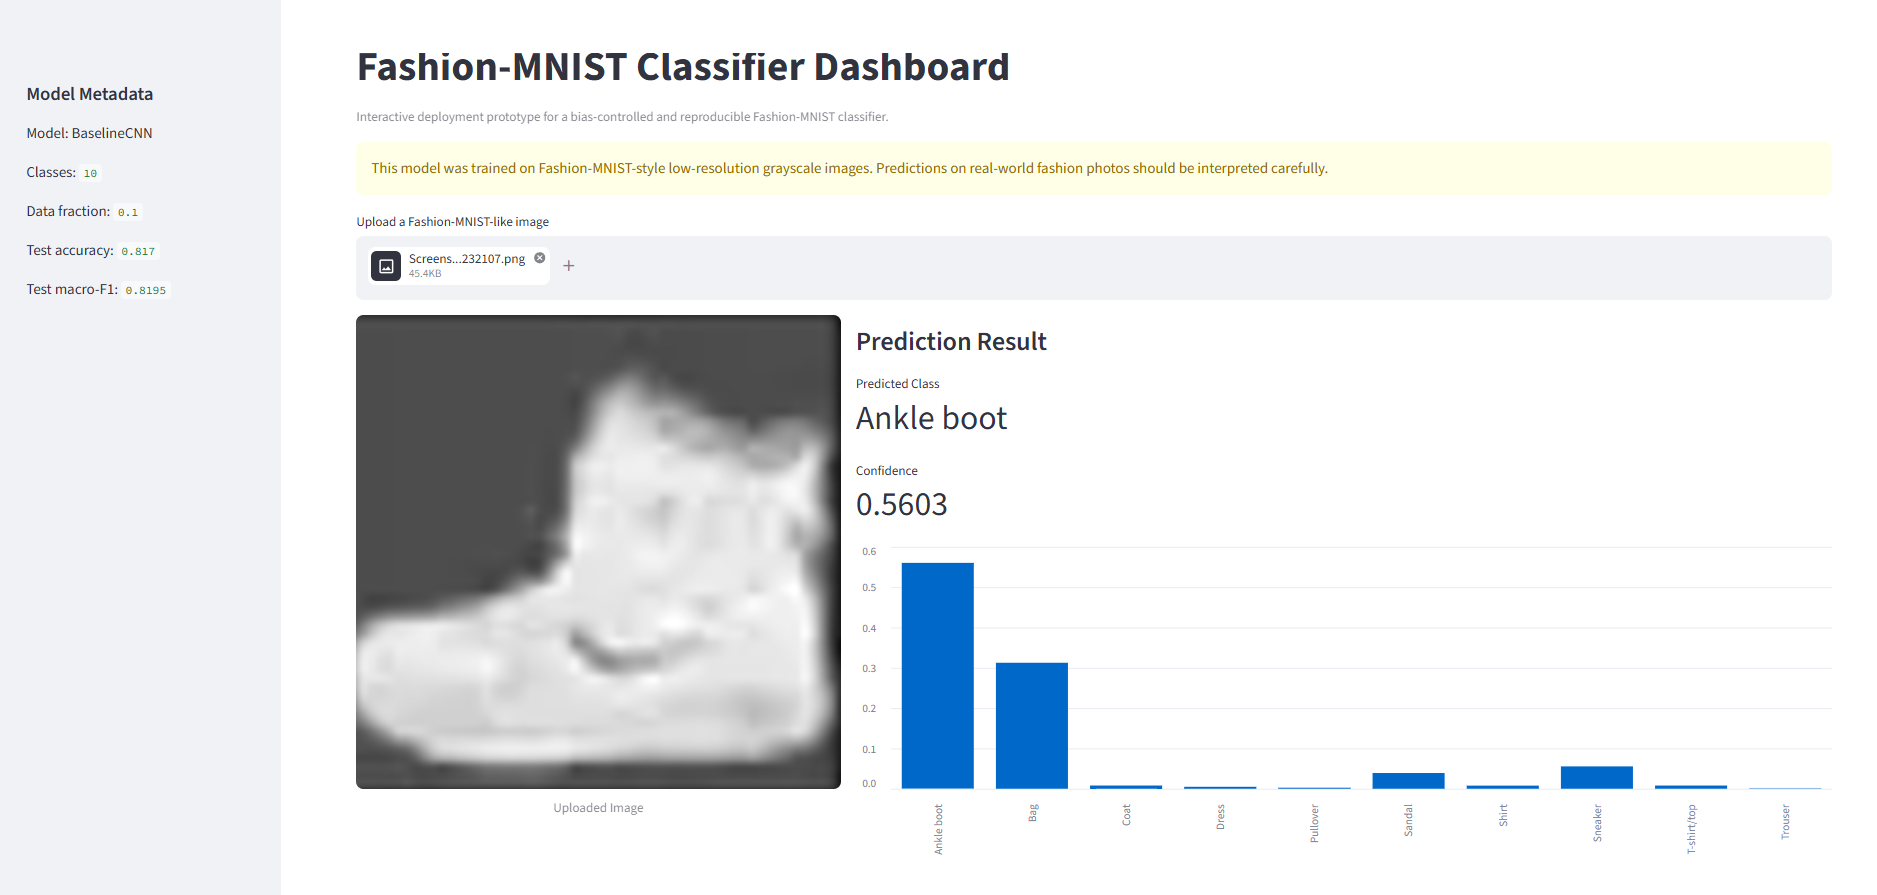

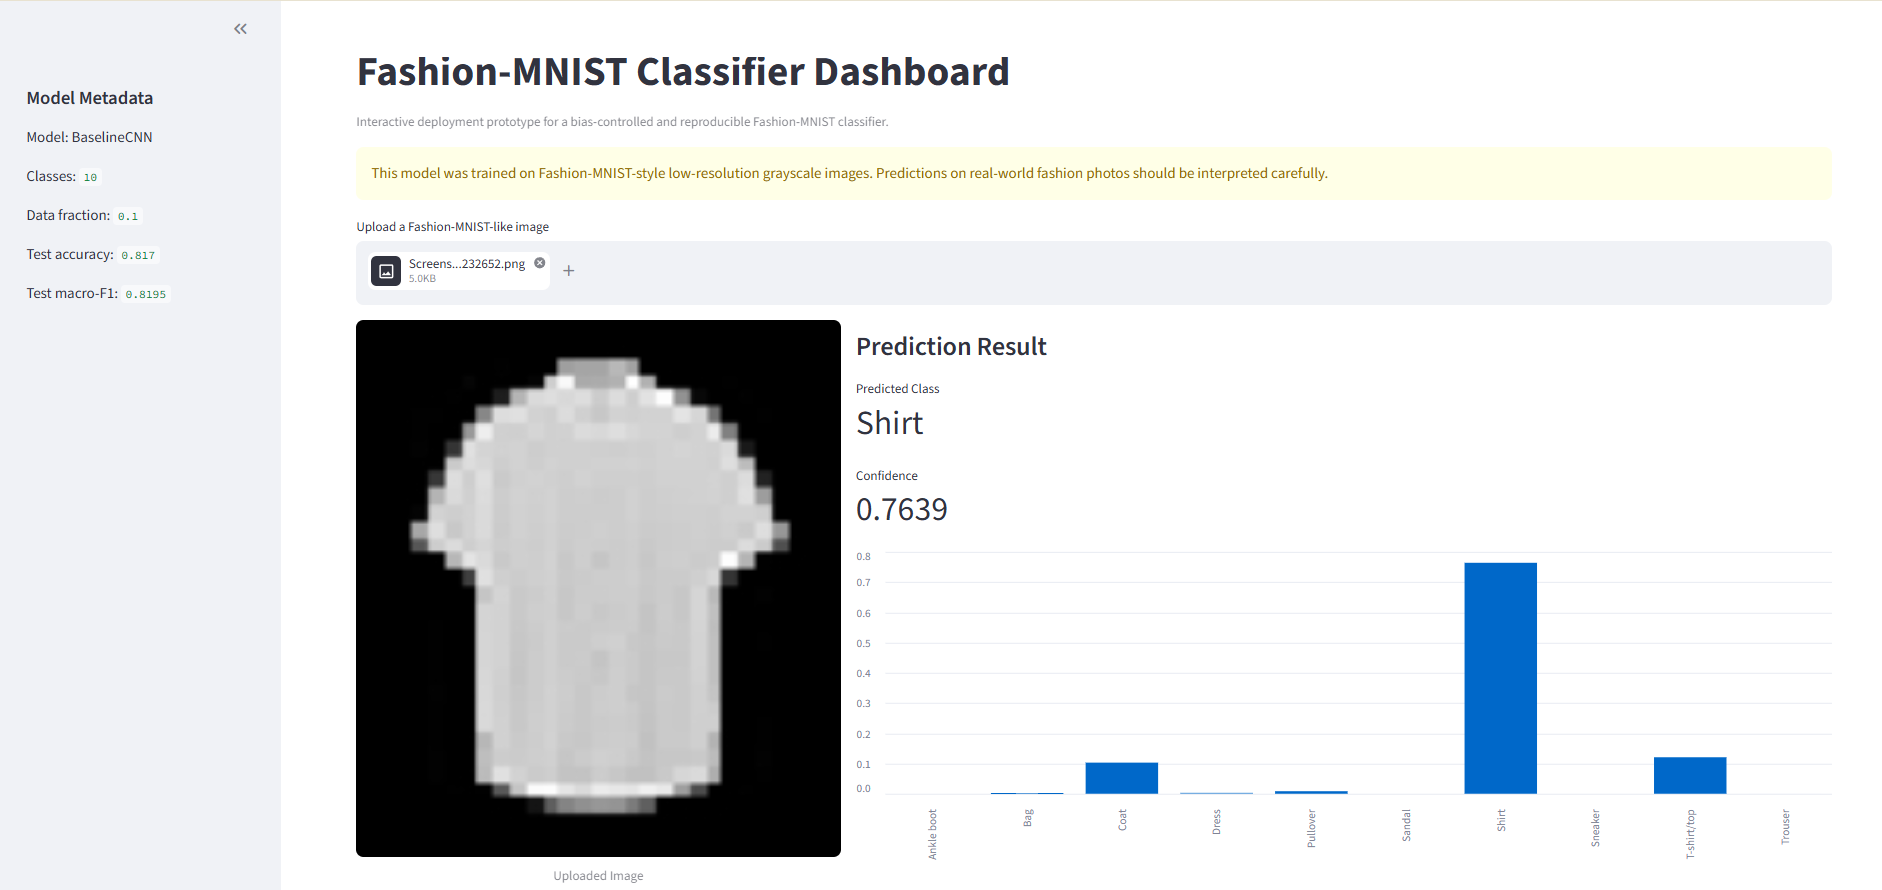